In [3]:
import sys
sys.path.append('/content/regressors_tests/bin')


In [5]:
!pip install pyDOE3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.7 MB/s eta 0:00:00


In [98]:
# Импортируем нужные библиотеки
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # класс разбиения на данные для обучения и для проверки
from sklearn.preprocessing import MinMaxScaler
# импортируем функции
from functions import plot_true_vs_predicted,  Functions, Generate_natural_data, Generate_coded_data

In [53]:
!git clone https://github.com/AlexanderASidorov/regressors_tests.git

fatal: destination path 'regressors_tests' already exists and is not an empty directory.


In [121]:
# Исходные данные
# создаем объект класса Functions
main_function = Functions()


# определяем количетсво строк для обучения
main_function.n_samples = 27

# пределы варьирования признаков
main_function.limits = (-10, 10)

# определяем вид функции
main_function.set_function(main_function.trigonometric)

# признаки переопределим с помощью ПФЭ
data_generator = Generate_coded_data(main_function,main_function.n_samples,
                               random_seed = main_function.random_seed)
data_generator.set_matrix_type("lhs")
main_function.features = data_generator.X_coded

main_function.n_samples = data_generator.n_samples

In [122]:
# Генерация пула кандидатов (случайные точки в допустимом диапазоне)
rng = np.random.default_rng(seed=12345)
X_pool = rng.uniform(low=-1.0, high=1.0, size=(10000, main_function.n_features))


In [123]:
print(main_function.features)

[[-0.49489359 -0.95287886 -0.05044521]
 [-0.69967357 -0.34117591 -0.01574674]
 [-0.35519839  0.97555493  0.3927932 ]
 [-0.31067526  0.88265228 -0.2360701 ]
 [ 0.91027545 -0.28373097  0.13168022]
 [ 0.6874198  -0.74075661 -0.83958377]
 [-0.43481008  0.05890602 -0.4046592 ]
 [ 0.40799902  0.51841226 -0.71184106]
 [ 0.27977391  0.65603668  0.53182967]
 [-0.83758032 -0.85813756 -0.47868746]
 [-0.57165669  0.3871054   0.25008347]
 [ 0.23771463 -0.83753312  0.61938103]
 [ 0.12980033 -0.45573741  0.79103142]
 [ 0.34659077 -0.48230668 -0.69504151]
 [ 0.59607941  0.32592963 -0.89621831]
 [ 0.95814223 -0.59114619  0.87287343]
 [ 0.72111195 -0.04794929  0.70881473]
 [ 0.54441636  0.70871275  0.04396774]
 [-0.13533118  0.42439697 -0.30763648]
 [-0.088723   -0.16807933 -0.61514928]
 [-0.00800407  0.23663498  0.95835197]
 [-0.85851681  0.55765995 -0.50866888]
 [-0.97960984 -0.6424073  -0.12025857]
 [ 0.78733756  0.11888452 -0.98331808]
 [-0.74643595  0.78155465  0.47345598]
 [-0.23998081  0.01628667

In [124]:
print(main_function.features[0])

[-0.49489359 -0.95287886 -0.05044521]


In [125]:
class TargetFunctionSin(Functions):
  def __init__(self,main_function, main_function_name, random_seed, n_samples, n_features, features, limits, target, rng):
    super().__init__()
    self.main_function = main_function
    self.main_function_name = main_function_name
    self.random_seed  = random_seed
    self.n_samples = n_samples
    self.n_features = n_features
    self.limits = limits
    self.features = features
    self.target = target
    self.rng = rng

  @classmethod
  def from_parent(cls, parent_instance, target, rng):
    return cls(main_function=parent_instance, main_function_name=parent_instance.main_function_name, random_seed=parent_instance.random_seed, n_samples=parent_instance.n_samples, n_features=parent_instance.n_features,features=parent_instance.features,limits= parent_instance.limits, target=target, rng=rng)
  def gen_target(self):
    for i in range(self.features.shape[0]):
            x1 = self.features[i,0]
            x2 = self.features[i,1]
            x3 = self.features[i,2]
            value = self.trigonometric(x1, x2, x3)
            self.target.append(value)

    self.target = np.array(self.target)
    return self.target
  def function(self, x1, x2, x3):
    return self.trigonometric(x1, x2, x3)



In [126]:
main_function = TargetFunctionSin.from_parent(main_function, [], rng)

In [127]:
main_function.gen_target()

array([-0.04289991, -0.38528274, -0.30040991, -0.60615749, -0.30447142,
        0.14388672, -0.48493759,  0.42828169,  0.63637929, -0.07807138,
        0.2627783 ,  0.47593191, -0.15252396, -0.11806181,  0.63374297,
       -0.62153602,  0.13625396,  0.38328111, -0.10514856, -0.43786067,
       -0.07676509,  0.08708896,  0.02892336,  0.43345655,  0.21892641,
        0.02957675, -0.04476771])

In [128]:
print(main_function.target)

[-0.04289991 -0.38528274 -0.30040991 -0.60615749 -0.30447142  0.14388672
 -0.48493759  0.42828169  0.63637929 -0.07807138  0.2627783   0.47593191
 -0.15252396 -0.11806181  0.63374297 -0.62153602  0.13625396  0.38328111
 -0.10514856 -0.43786067 -0.07676509  0.08708896  0.02892336  0.43345655
  0.21892641  0.02957675 -0.04476771]


In [139]:
# Попробуем определить точку, которую желательно добавить в массив для обучения
# Обучаем ансамбль из N моделей
n_models = 30
predictions = []

for i in range(n_models):
    model = XGBRegressor(
                    n_estimators=1000,
                    max_depth=3,
                    learning_rate=0.1,
                    reg_alpha=0.5,
                    reg_lambda=0.5,
                    subsample=0.8,
                    random_state=1488+i,
                    verbosity=0
                    )
    model.fit(main_function.features, main_function.target)
    pred = model.predict(X_pool)
    predictions.append(pred)

# Считаем дисперсию предсказаний по ансамблю
predictions = np.array(predictions)  # (n_models, n_pool)
uncertainty = predictions.std(axis=0)  # (n_pool,)

# Выбираем точку с максимальной неопределённостью
best_idx = np.argmax(uncertainty)
features_to_add = X_pool[best_idx]
# Определяем значение целевой переменной при данных знаениях признаков
target_to_add = main_function.function(*features_to_add.T)


print(f'Следующая точка для замера - точка # {best_idx}')
print (f'Ее неопределенность равна: {uncertainty[best_idx]:.5f}')
print (f'Необходимо добавить в массив признаков следующие данные: {features_to_add}')
print (f'Значение целевой функции для данной точки будет: {target_to_add}')
print("Макс. неопределённость:", uncertainty.max())
print("Средняя неопределённость:", uncertainty.mean())
print("Медиана:", np.median(uncertainty))
print("Количество точек с uncertainty > 90%-квантиля:", np.sum(uncertainty > np.percentile(uncertainty, 90)))

Следующая точка для замера - точка # 7376
Ее неопределенность равна: 0.02924
Необходимо добавить в массив признаков следующие данные: [ 0.04014225 -0.95680649  0.86905771]
Значение целевой функции для данной точки будет: 0.18755947360163067
Макс. неопределённость: 0.02923996
Средняя неопределённость: 0.014139311
Медиана: 0.013883855
Количество точек с uncertainty > 90%-квантиля: 990


In [140]:
n_active_iterations = 100
history = []

for iteration in range(n_active_iterations):
    print(f"iter:{iteration + 1}")
    predictions = []
    for i in range(n_models):
        model = XGBRegressor(n_estimators=1000,max_depth=3,learning_rate=0.1,reg_alpha=0.5,reg_lambda=0.5,subsample=0.8,random_state=1488+i,verbosity=0)
        model.fit(main_function.features, main_function.target)
        pred = model.predict(X_pool)
        predictions.append(pred)
    predictions = np.array(predictions)
    uncertainty = predictions.std(axis=0)
    best_idx = np.argmax(uncertainty)
    features_to_add = X_pool[best_idx]
    target_to_add = main_function.trigonometric(features_to_add[0], features_to_add[1], features_to_add[2])
    history.append({'iter': iteration,'uncertainty': uncertainty[best_idx],'features': features_to_add,'target': target_to_add})
    print(f"неопределенность: {uncertainty[best_idx]:.6f}")
    print(f"точка: [{features_to_add[0]:.4f}, {features_to_add[1]:.4f}, {features_to_add[2]:.4f}]")
    print(f"значение: {target_to_add:.6f}")
    main_function.features = np.vstack([main_function.features, features_to_add])
    main_function.target = np.append(main_function.target, target_to_add)
    X_pool = np.delete(X_pool, best_idx, axis=0)
    print(f"новый размер выборки: {len(main_function.target)}")
print("итоги")
for record in history:
    print(f"итерация {record['iter']+1}: неопред={record['uncertainty']:.6f}, таргетн={record['target']:.6f}")

iter:1
неопределенность: 0.029240
точка: [0.0401, -0.9568, 0.8691]
значение: 0.187559
новый размер выборки: 128
iter:2
неопределенность: 0.029857
точка: [-0.5014, 0.8653, -0.8980]
значение: -0.204946
новый размер выборки: 129
iter:3
неопределенность: 0.030595
точка: [-0.0043, -0.7290, -0.1976]
значение: -0.260375
новый размер выборки: 130
iter:4
неопределенность: 0.029339
точка: [0.7436, -0.6956, 0.0325]
значение: -0.025576
новый размер выборки: 131
iter:5
неопределенность: 0.026545
точка: [0.7447, 0.5876, 0.8696]
значение: 0.140837
новый размер выборки: 132
iter:6
неопределенность: 0.027304
точка: [0.5578, -0.6464, 0.8714]
значение: -0.063500
новый размер выборки: 133
iter:7
неопределенность: 0.029162
точка: [0.1387, -0.2332, 0.7712]
значение: -0.053663
новый размер выборки: 134
iter:8
неопределенность: 0.027039
точка: [-0.0764, 0.7686, -0.9740]
значение: 0.252578
новый размер выборки: 135
iter:9
неопределенность: 0.026596
точка: [-0.0817, -0.6771, 0.8245]
значение: -0.272525
новый ра

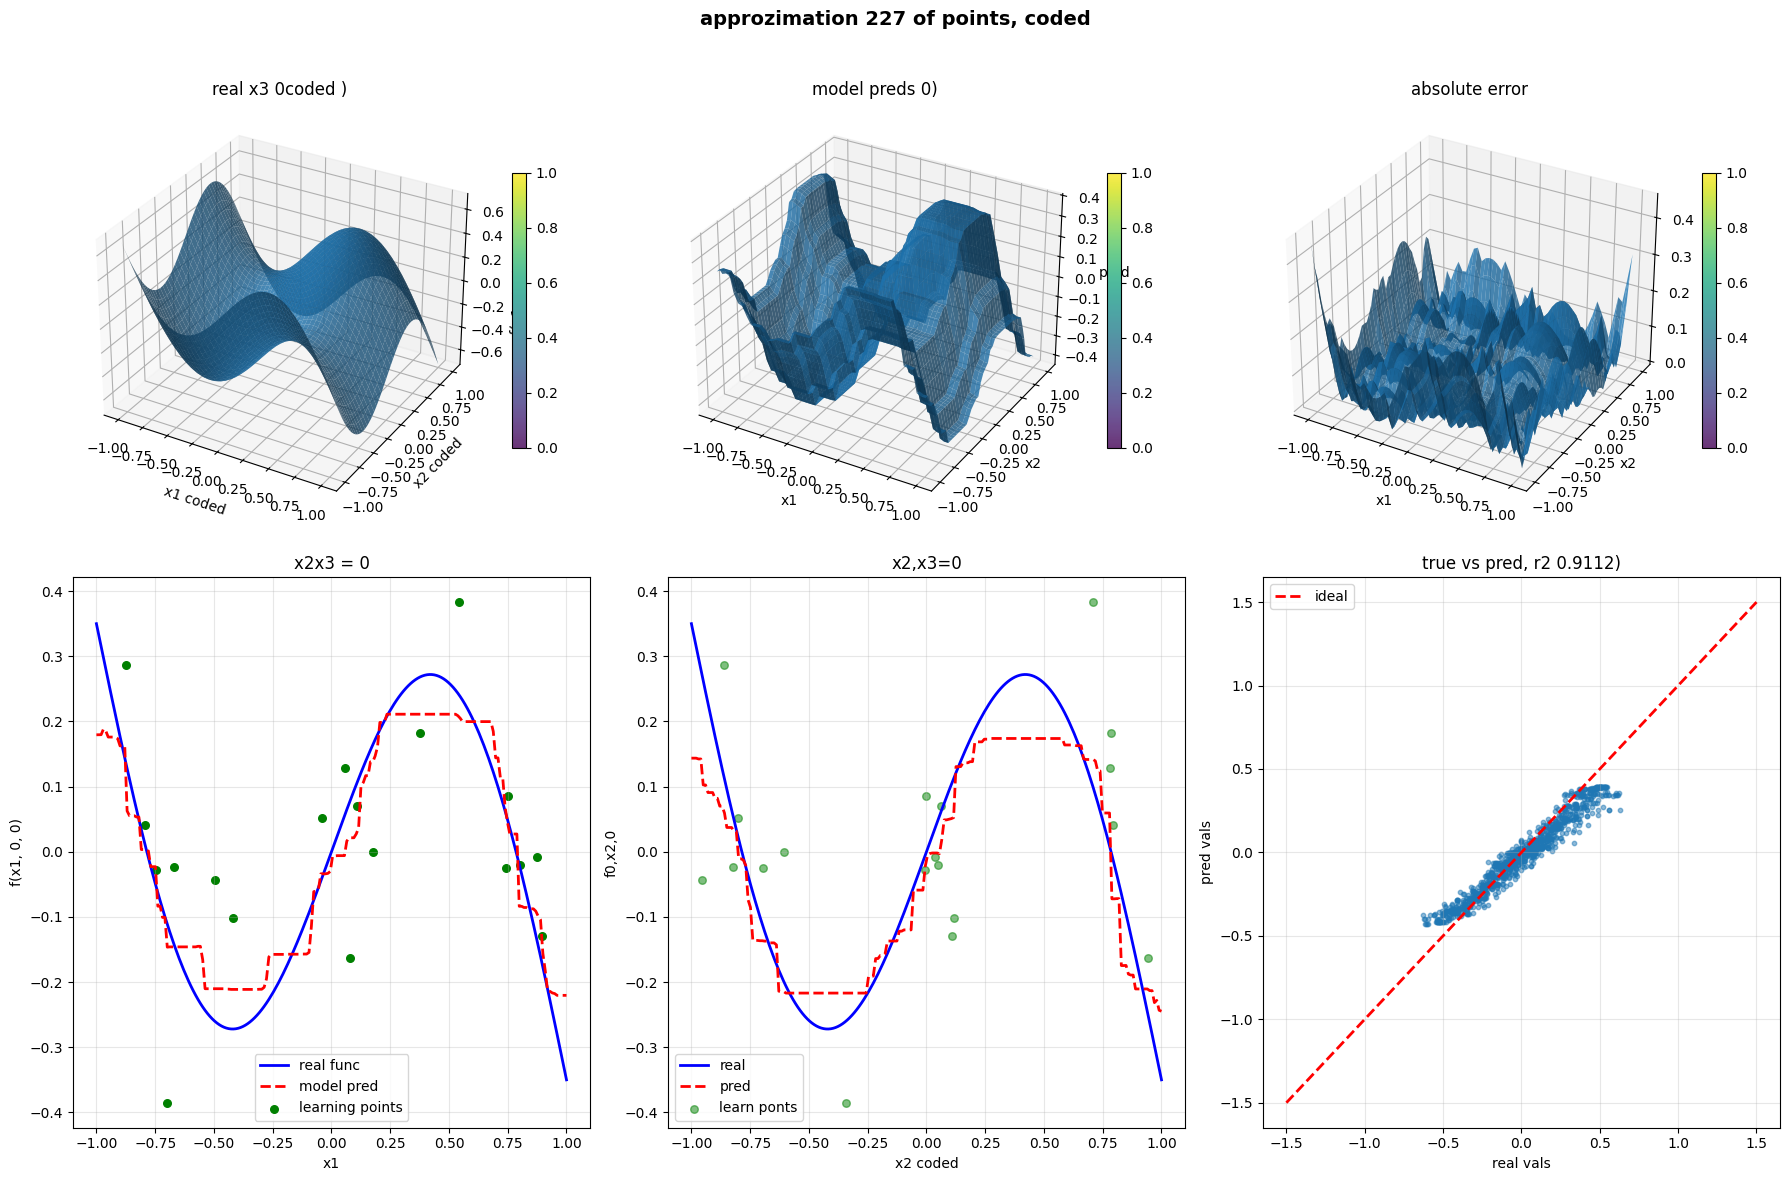

R2: 0.9105
RMSE: 0.0845
MAE 0.0656
max error 0.4551
in percents of diapasone 4.7%


In [141]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

n_grid=50
x1_grid=np.linspace(-1, 1, n_grid)
x2_grid=np.linspace(-1, 1, n_grid)
x3_fixed=0

X1,X2 = np.meshgrid(x1_grid,x2_grid)
X_grid =np.column_stack([X1.ravel(),X2.ravel(),np.full(X1.ravel().shape,x3_fixed)])

Z_true = np.array([main_function.trigonometric(x[0], x[1], x[2]) for x in X_grid])
final_model = XGBRegressor(n_estimators=1000,max_depth=3,learning_rate=0.1,reg_alpha=0.5,reg_lambda=0.5,subsample=0.8,random_state=1488,verbosity=0)
final_model.fit(main_function.features, main_function.target)
Z_pred = final_model.predict(X_grid)
Z_true_2d = Z_true.reshape(n_grid, n_grid)
Z_pred_2d = Z_pred.reshape(n_grid, n_grid)
Z_error_2d = np.abs(Z_true_2d - Z_pred_2d)
train_points_x1 = []
train_points_x2 = []
train_points_z = []

for i in range(len(main_function.features)):
    x1, x2, x3 = main_function.features[i]
    if abs(x3) < 0.1:
        train_points_x1.append(x1)
        train_points_x2.append(x2)
        train_points_z.append(main_function.target[i])
fig = plt.figure(figsize=(18, 12))
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X1, X2, Z_true_2d,alpha=0.8)
ax1.set_title(f'real x3 {x3_fixed}coded )', fontsize=12)
ax1.set_xlabel('x1 coded')
ax1.set_ylabel('x2 coded')
ax1.set_zlabel('f(x1,x2,0) surface')
fig.colorbar(surf1,ax=ax1,shrink=0.5)
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z_pred_2d,alpha=0.8)
ax2.set_title(f'model preds {x3_fixed})', fontsize=12)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('pred')
fig.colorbar(surf2,ax=ax2,shrink=0.5)
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X1, X2, Z_error_2d, alpha=0.8)
ax3.set_title(f'absolute error', fontsize=12)
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('error')
fig.colorbar(surf3, ax=ax3, shrink=0.5)
ax4 = fig.add_subplot(2, 3, 4)
x1_line = np.linspace(-1, 1, 200)
x2_fixed_section = 0
x3_fixed_section = 0
true_line = [main_function.trigonometric(x, x2_fixed_section, x3_fixed_section) for x in x1_line]
pred_line = final_model.predict(np.column_stack([x1_line, np.full_like(x1_line, x2_fixed_section), np.full_like(x1_line, x3_fixed_section)]))
ax4.plot(x1_line, true_line,'b-',linewidth=2, label='real func')
ax4.plot(x1_line, pred_line,'r--',linewidth=2, label='model pred')
ax4.scatter(train_points_x1, train_points_z, c='green', s=30, label='learning points')
ax4.set_xlabel('x1')
ax4.set_ylabel('f(x1, 0, 0)')
ax4.set_title('x2x3 = 0')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax5 = fig.add_subplot(2, 3, 5)
x2_line = np.linspace(-1, 1, 200)
x1_fixed_section = 0

true_line2 = [main_function.trigonometric(x1_fixed_section,x,x3_fixed_section) for x in x2_line]
pred_line2 = final_model.predict(np.column_stack([np.full_like(x2_line,x1_fixed_section),x2_line,np.full_like(x2_line,x3_fixed_section)]))

ax5.plot(x2_line, true_line2, 'b-', linewidth=2, label='real')
ax5.plot(x2_line, pred_line2, 'r--',linewidth=2, label='pred')
ax5.scatter(train_points_x2, train_points_z, c='green', s=30, alpha=0.5, label='learn ponts')
ax5.set_xlabel('x2 coded')
ax5.set_ylabel('f0,x2,0')
ax5.set_title('x2,x3=0')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax6 = fig.add_subplot(2, 3, 6)
indices = np.random.choice(len(Z_true), min(1000, len(Z_true)), replace=False)
true_flat = Z_true[indices]
pred_flat = Z_pred[indices]

ax6.scatter(true_flat, pred_flat, alpha=0.5,s=10)
ax6.plot([-1.5, 1.5], [-1.5, 1.5], 'r--', linewidth=2,label='ideal')
ax6.set_xlabel('real vals')
ax6.set_ylabel('pred vals')
ax6.set_title(f'true vs pred, r2 {r2_score(true_flat, pred_flat):.4f})')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle(f'approzimation {len(main_function.target)} of points, coded',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"R2: {r2_score(Z_true, Z_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Z_true, Z_pred)):.4f}")
print(f"MAE {np.mean(np.abs(Z_true - Z_pred)):.4f}")
print(f"max error {np.max(np.abs(Z_true - Z_pred)):.4f}")
print(f"in percents of diapasone {np.mean(np.abs(Z_true - Z_pred)) / (Z_true.max() - Z_true.min()) * 100:.1f}%")